<a href="https://colab.research.google.com/github/arsalanmontazeri/Arsalan-Montazeri/blob/tesla/Tesla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# For displaying all of the columns in dataframes
pd.set_option('display.max_column',None)
# For data modeling
from xgboost import XGBClassifier
from xgboost import plot_importance
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
# For saving models
import pickle
import plotly.express as px
import geopandas as gpd

In [2]:
tesla=pd.read_csv('TESLA.csv')

In [3]:
tesla.head()

,Unnamed: 0,Date,Open,High,Low,Close,Adj Close,Volume
0,0,6/29/10,1.266667,1.666667,1.169333,1.592667,1.592667,281494500
1,1,6/30/10,1.719333,2.028000,1.553333,1.588667,1.588667,257806500
2,2,7/1/10,1.666667,1.728000,1.351333,1.464000,1.464000,123282000
3,3,7/2/10,1.533333,1.540000,1.247333,1.280000,1.280000,77097000
4,4,7/6/10,1.333333,1.333333,1.055333,1.074000,1.074000,103003500


In [4]:
tesla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3637 entries, 0 to 3636
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  3637 non-null   int64  
 1   Date        3637 non-null   object 
 2   Open        3637 non-null   float64
 3   High        3637 non-null   float64
 4   Low         3637 non-null   float64
 5   Close       3637 non-null   float64
 6   Adj Close   3637 non-null   float64
 7   Volume      3637 non-null   int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 227.4+ KB


In [5]:
tesla=tesla.drop(columns='Unnamed: 0',axis=1)

In [6]:
tesla.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,6/29/10,1.266667,1.666667,1.169333,1.592667,1.592667,281494500
1,6/30/10,1.719333,2.028000,1.553333,1.588667,1.588667,257806500
2,7/1/10,1.666667,1.728000,1.351333,1.464000,1.464000,123282000
3,7/2/10,1.533333,1.540000,1.247333,1.280000,1.280000,77097000
4,7/6/10,1.333333,1.333333,1.055333,1.074000,1.074000,103003500


In [7]:
tesla.shape

(3637, 7)

In [8]:
tesla['Date']=pd.to_datetime(tesla['Date'])
tesla['Year']=tesla['Date'].dt.year
tesla['Month']=tesla['Date'].dt.month
tesla['Day']=tesla['Date'].dt.day

<ipython-input-8-f69c2c2b94b0>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tesla['Date']=pd.to_datetime(tesla['Date'])


In [9]:
tesla.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,2010-06-29,1.266667,1.666667,1.169333,1.592667,1.592667,281494500,2010,6,29
1,2010-06-30,1.719333,2.028000,1.553333,1.588667,1.588667,257806500,2010,6,30
2,2010-07-01,1.666667,1.728000,1.351333,1.464000,1.464000,123282000,2010,7,1
3,2010-07-02,1.533333,1.540000,1.247333,1.280000,1.280000,77097000,2010,7,2
4,2010-07-06,1.333333,1.333333,1.055333,1.074000,1.074000,103003500,2010,7,6


In [10]:
tesla.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Year,0
Month,0
Day,0


<Axes: xlabel='Year'>

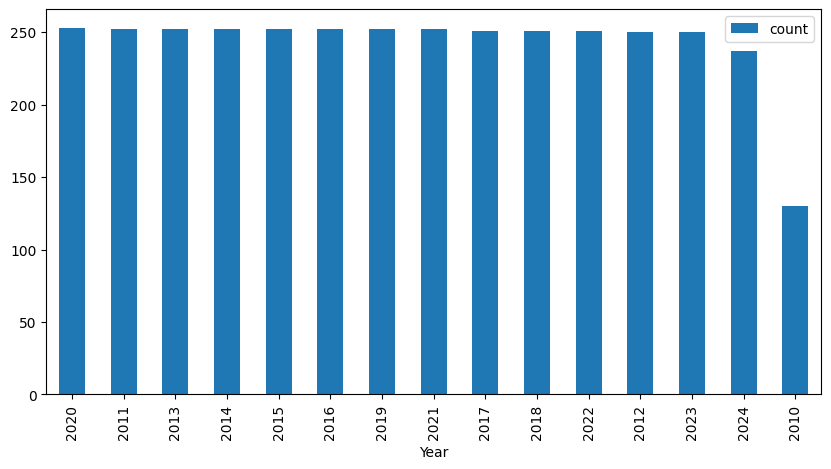

In [11]:
tesla['Year'].value_counts().reset_index().plot(kind='bar',x='Year',y='count',figsize=(10,5))

<ipython-input-12-583ba5155253>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dailly_avg.index, y=dailly_avg.values, palette="viridis")


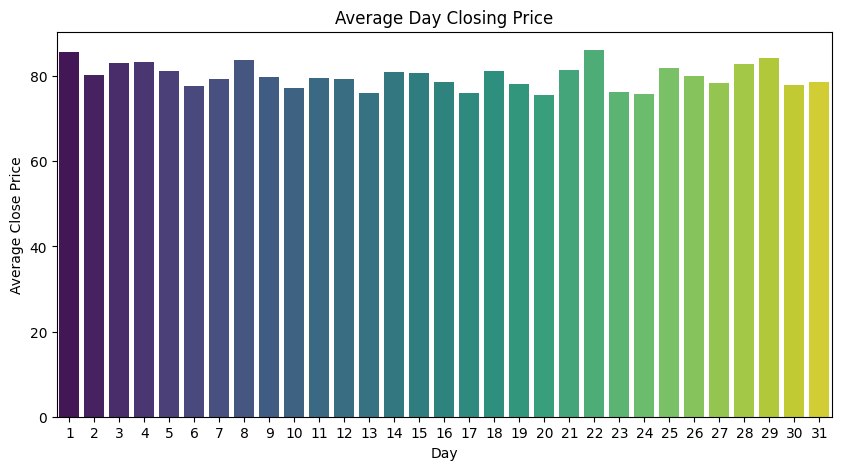

In [12]:
dailly_avg = tesla.groupby('Day')['Close'].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=dailly_avg.index, y=dailly_avg.values, palette="viridis")
plt.title('Average Day Closing Price')
plt.xlabel('Day')
plt.ylabel('Average Close Price')
plt.show()

<ipython-input-13-6ad73f66a29a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette="viridis")


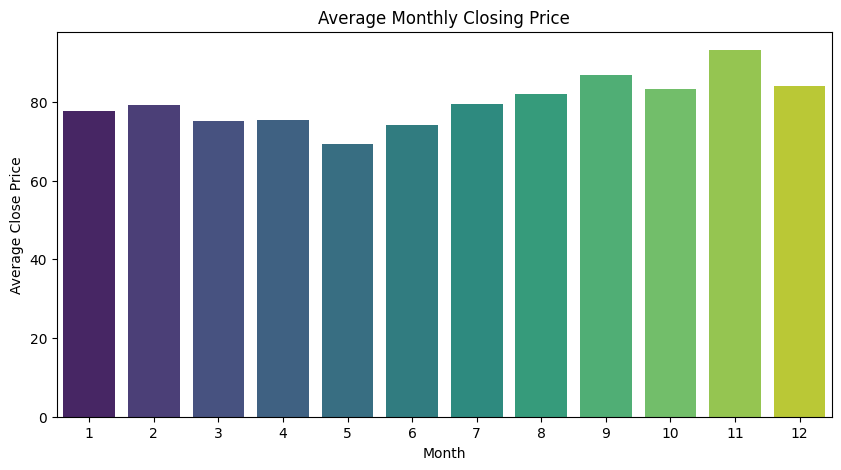

In [13]:
monthly_avg = tesla.groupby('Month')['Close'].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette="viridis")
plt.title('Average Monthly Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.show()



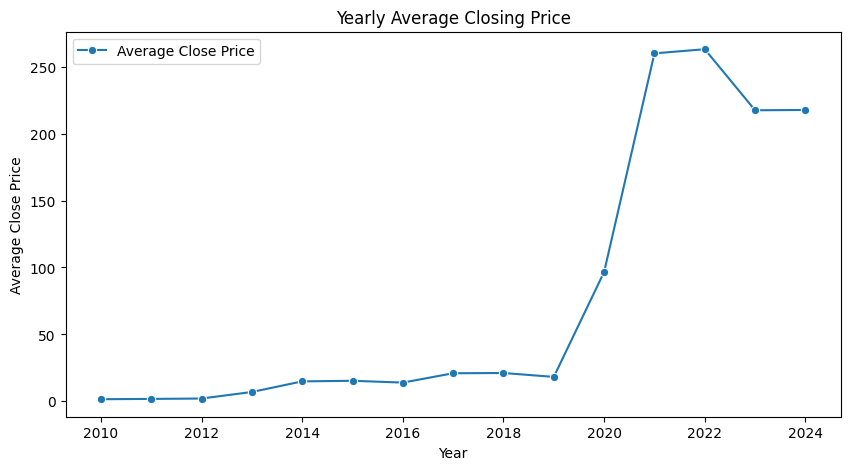

In [14]:
yearly_avg = tesla.groupby('Year')['Close'].mean()
yearly_volatility = tesla.groupby('Year')['Close'].std()

# Visualize yearly average closing prices
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='o', label='Average Close Price')
plt.title('Yearly Average Closing Price')
plt.xlabel('Year')
plt.ylabel('Average Close Price')
plt.legend()
plt.show()

<ipython-input-15-07584db986b9>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_volatility.index, y=yearly_volatility.values, palette="coolwarm")


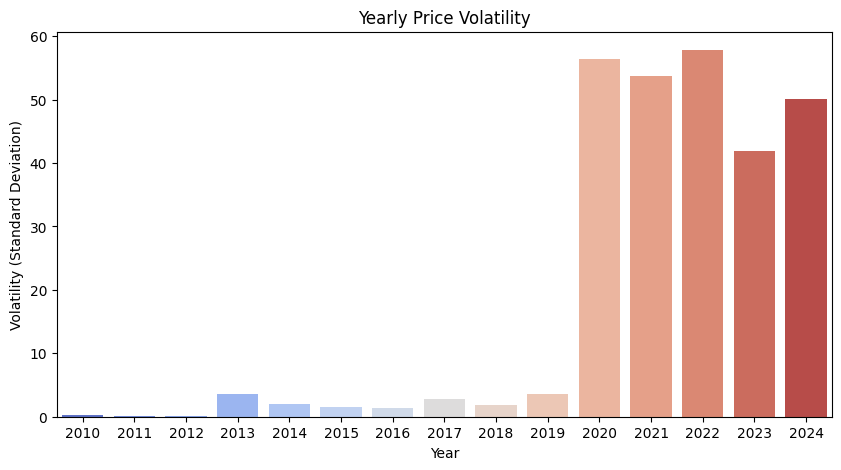

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(x=yearly_volatility.index, y=yearly_volatility.values, palette="coolwarm")
plt.title('Yearly Price Volatility')
plt.xlabel('Year')
plt.ylabel('Volatility (Standard Deviation)')
plt.show()

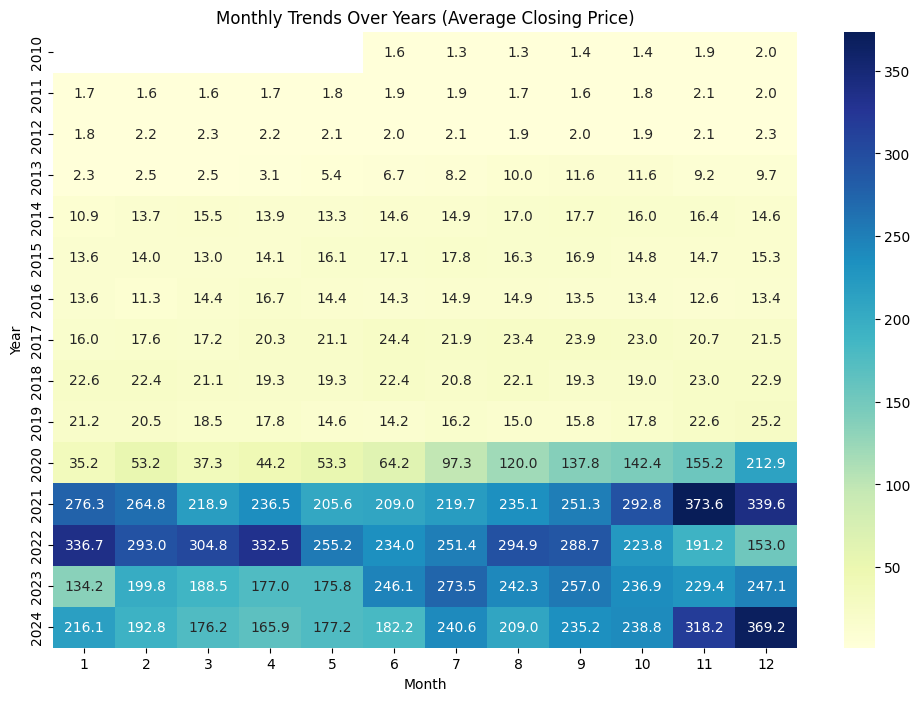

In [16]:
monthly_trends = tesla.groupby(['Year', 'Month'])['Close'].mean().reset_index()

pivot_table = monthly_trends.pivot(index='Year', columns='Month', values='Close')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Monthly Trends Over Years (Average Closing Price)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()


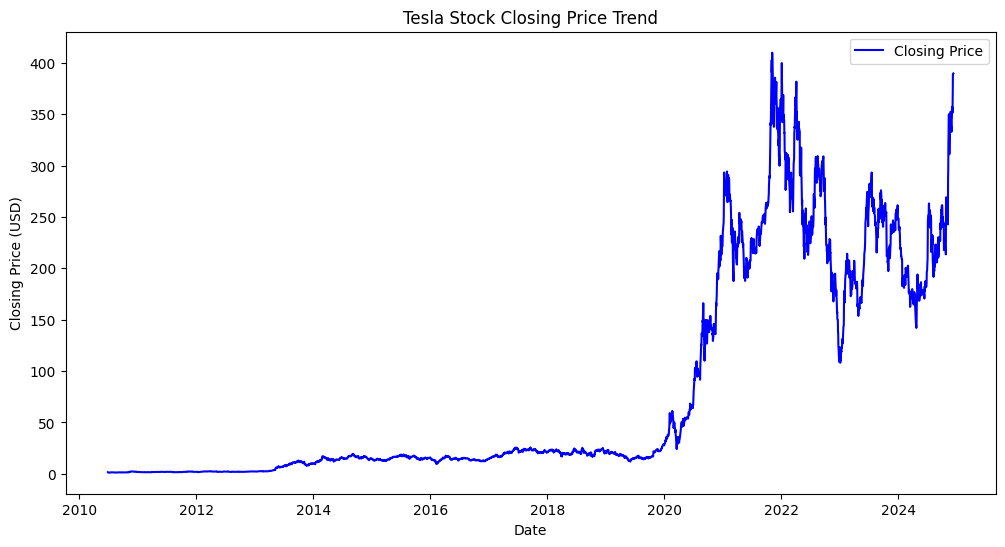

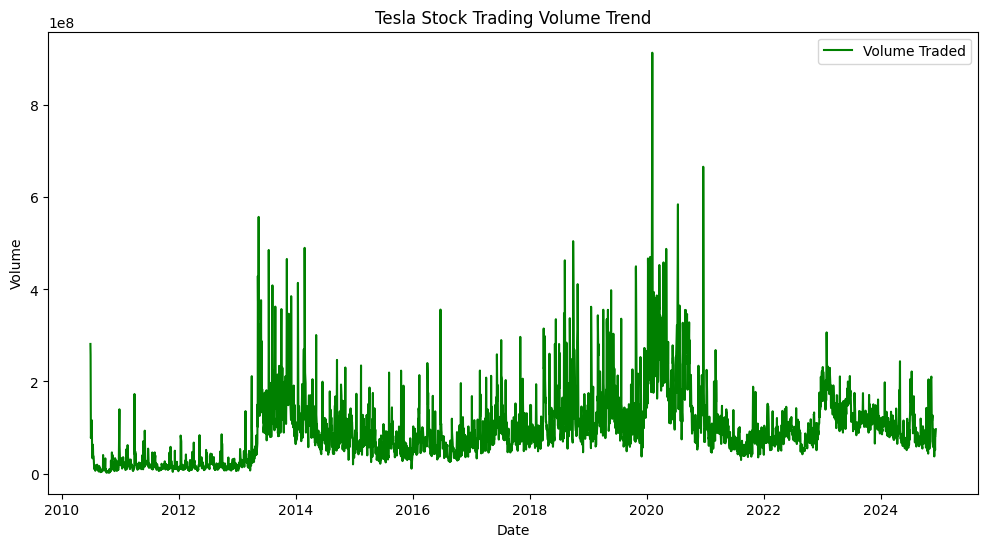

In [17]:
# Plot closing price trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=tesla, x='Date', y='Close', label='Closing Price', color='blue')
plt.title('Tesla Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

# Plot volume trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=tesla, x='Date', y='Volume', label='Volume Traded', color='green')
plt.title('Tesla Stock Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()


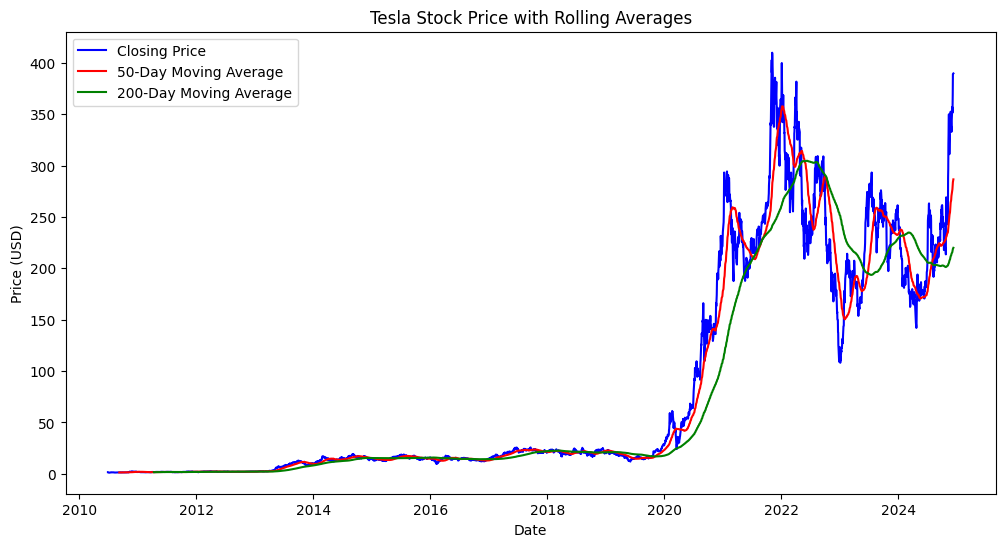

In [18]:
# Calculate rolling averages
tesla['50_Day_MA'] = tesla['Close'].rolling(window=50).mean()
tesla['200_Day_MA'] = tesla['Close'].rolling(window=200).mean()

# Plot rolling averages
plt.figure(figsize=(12, 6))
sns.lineplot(data=tesla, x='Date', y='Close', label='Closing Price', color='blue')
sns.lineplot(data=tesla, x='Date', y='50_Day_MA', label='50-Day Moving Average', color='red')
sns.lineplot(data=tesla, x='Date', y='200_Day_MA', label='200-Day Moving Average', color='green')
plt.title('Tesla Stock Price with Rolling Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


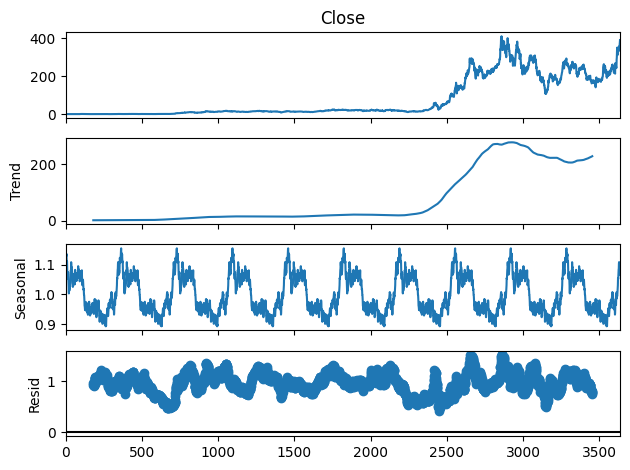

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the closing price series
result = seasonal_decompose(tesla['Close'], model='multiplicative', period=365)

# Plot the decomposed components
result.plot()
plt.show()


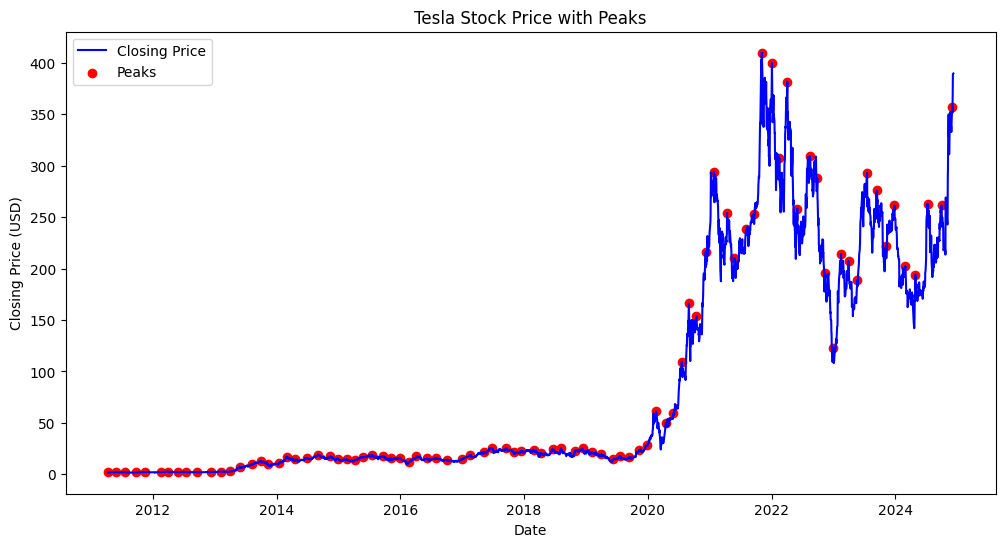

In [24]:
from scipy.signal import find_peaks


peaks, _ = find_peaks(tesla['Close'], distance=30)

plt.figure(figsize=(12, 6))
plt.plot(tesla['Date'], tesla['Close'], label='Closing Price', color='blue')
plt.scatter(tesla['Date'].iloc[peaks], tesla['Close'].iloc[peaks], color='red', label='Peaks')
plt.title('Tesla Stock Price with Peaks')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Create lag features
tesla['Prev_Close'] = tesla['Close'].shift(1)

# Drop rows with NaN values
tesla.dropna(inplace=True)

# Define features and target
features = ['Prev_Close', '50_Day_MA', '200_Day_MA', 'Volume']
X = tesla[features]
y = tesla['Close']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")


RMSE: 5.175996570590365


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}


In [23]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Optimized RMSE: {rmse}")

Optimized RMSE: 5.116752362832503
